In [1]:
import os
import sys
import pickle
from glob import glob
from warnings import filterwarnings
from colorsys import hsv_to_rgb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from data_readers.radar import RadarData
from data_readers.visualize import MatPlot3D

np.set_printoptions(precision=12, suppress=True)
filterwarnings("ignore", category=DeprecationWarning)

DATASET_PATH = os.path.abspath("../../../RF-Behavior")
DATASET_PATH, os.path.exists(DATASET_PATH)

('c:\\RF-Behavior', True)

## Radar

In [2]:
path = "../../../RF-Behavior/Radar/C2/U01/A02/01/"
rd = RadarData.read_from_path(path)
rdb = rd.bin(fps=10, int_time=True)
print(len(rdb.points), len(rdb.radar_ids), len(rdb.timestamps),rdb.timestamps, rdb.fps)

80 80 80 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79] 10


In [5]:
# path = "../../../RF-Behavior/Radar/C1/U03/M08/01/" # "swipe-left"  # azimuth=0, elevation=90
path = "../../../RF-Behavior/Radar/C2/U03/A01/01/"  # walking # +z = above
# path = "../../../RF-Behavior/Radar/C3/U03/E01/01/"  # focus
fps = 2
rdbp = RadarData.read_from_path(path, normalize=False).bin(fps=fps).pad()
points = np.array(rdbp.points)[:, :, :3]
print(points.shape)

anim = MatPlot3D.animate(points, vertical_axis="z", azimuth=10, elevation=20,
    scatter_colors=[[(RadarData.COLORS[i] if i is not None else (0,0,0,0)) for i in r] for r in rdbp.radar_ids], scatter_size=2, ticks_scale=1,
    )
plt.close()
display(HTML(anim.to_jshtml(fps=10)))

(30, 271, 3)


In [7]:
rdbp.timestamps[-1] - rdbp.timestamps[0]

np.float64(14.5)

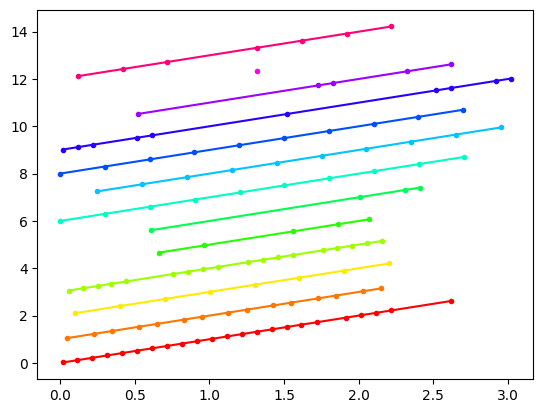

In [ ]:
ts = [[ t[0,0] for t in p if len(t)] for _, p in sorted(RadarData.read_pickles(path).items())]
min_ts = min(min(t) for t in ts)
ts = [[v-min_ts for v in t] for t in ts]
for i, t in enumerate(ts):
    plt.plot(t, i+np.array(t), ".-", c=RadarData.COLORS[i])

In [ ]:
# from tqdm.auto import tqdm
# from concurrent.futures import ThreadPoolExecutor

# files = glob("../../../RF-Behavior/Radar/*/*/*/*")
# np.random.shuffle(files)

# def process_path(p):
#     rd = RadarData.read_from_path(p, transform=True, normalize=False)
#     concat = np.concatenate(rd.points, axis=0)
#     return concat.mean(axis=0), concat.std(axis=0), len(concat)

# with ThreadPoolExecutor(max_workers=16) as executor:
#     results = list(tqdm(executor.map(process_path, files), total=len(files)))
#     means, stds, ns = zip(*results)


In [ ]:
# np.average(means, axis=0, weights=ns),\
# np.average(stds, axis=0, weights=ns)

(array([ 0.032089453582,  0.265011873078,  1.821485130146, 17.835674109973]),
 array([1.21536512212 , 2.157523648347, 1.260789705373, 6.055741740021]))